In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [2]:
from sklearn.datasets import fetch_openml

In [3]:
mnist = fetch_openml("mnist_784")

In [4]:
X,y = mnist["data"] , mnist["target"]

In [5]:
X = X.to_numpy()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
...     X, y, test_size=0.33, random_state=42)

In [7]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [12]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [8]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [9]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [10]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [13]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=8, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.9282 - loss: 0.2379 - val_accuracy: 0.9715 - val_loss: 0.0882
Epoch 2/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.9757 - loss: 0.0830 - val_accuracy: 0.9840 - val_loss: 0.0501
Epoch 3/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 54s 37ms/step - accuracy: 0.9805 - loss: 0.0640 - val_accuracy: 0.9862 - val_loss: 0.0447
Epoch 4/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.9852 - loss: 0.0489 - val_accuracy: 0.9885 - val_loss: 0.0389
Epoch 5/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 70s 48ms/step - accuracy: 0.9878 - loss: 0.0412 - val_accuracy: 0.9892 - val_loss: 0.0344
Epoch 6/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 72s 49ms/step - accuracy: 0.9891 - loss: 0.0353 - val_accuracy: 0.9896 - val_loss: 0.0350
Epoch 7/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 63s 43ms/step - accuracy: 0.9909 - loss: 0.0287 - val_accuracy: 0.9912 - val_loss: 0.0306
Epoch 8/8
1466/1466 ━━━━━━━━━━━━━━━━━━━━ 61s 42ms/step - accuracy: 0.9921 - loss: 0

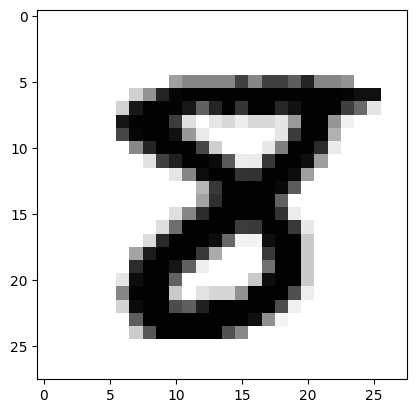

In [38]:
plt.imshow(X_test_cnn[0].reshape(28,28),cmap="binary")

In [39]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]

In [40]:
acc_cnn

0.9919913411140442

In [41]:
np.argmax(cnn.predict(X_test_cnn[0].reshape(1, 28, 28, 1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


np.int64(8)

In [42]:
cnn.save("mnist_cnn_model.h5")

In [44]:
import json


In [45]:
with open("data.json","r") as f:
    data = json.load(f)

In [48]:
pixels = [data[f'pixel_{i}'] for i in range(784)]
img = np.array(pixels, dtype=np.float32)

In [49]:
img = img.reshape(1, 28, 28, 1)

In [50]:
pred = cnn.predict(img)
digit = np.argmax(pred)

print("Predicted:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicted: 2
